# DFW County Location Intelligence — Dashboard Analysis

This notebook analyzes the stitched pilot dataset in `exports/county_dashboard.csv`.

**Pilot geography:** 5 core DFW counties (Collin, Dallas, Denton, Rockwall, Tarrant)

**Note:** Traffic columns are empty until HPMS/TxDOT data is loaded. Crime rates use a Texas state proxy, so cross-county crime comparison is limited.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

ROOT = Path.cwd()
if not (ROOT / "exports").exists() and (ROOT.parent / "exports").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "exports" / "county_dashboard.csv"
df = pd.read_csv(DATA_PATH)
df["county_fips"] = df["county_fips"].astype(str).str.zfill(5)

print(f"Loaded {len(df)} counties from {DATA_PATH}")
df.head()

Loaded 5 counties from c:\Users\kkr84\Projects\location-intelligence\exports\county_dashboard.csv


,county_label,county_role,county_fips,population,median_household_income,households,median_home_value,building_permits_latest,building_permits_year,permits_per_1k_households,...,property_crime_per_100k,burglary_per_100k,larceny_per_100k,general_location_score,score_population,score_income,score_growth,score_traffic,score_retail_density,score_crime
0,Collin,suburban_growth,48085,1163337,121600,416646,475600,19082,2025,45.799072,...,58585.775231,10179.337544,40306.463217,69.5,41.629397,87.593810,100.000000,50.0,61.734691,93.797499
1,Dallas,urban_core,48113,2621179,76547,982737,303000,12691,2025,12.913933,...,26001.658033,4517.814312,17888.896561,64.5,100.000000,0.000000,63.461209,50.0,100.000000,100.000000
2,Tarrant,urban_core,48439,2167390,84207,782419,323900,13924,2025,17.796091,...,31445.655835,5463.714421,21634.315928,64.3,81.830721,14.892872,70.510548,50.0,96.626703,98.963716
3,Denton,suburban_growth,48121,979561,111498,360392,437200,10210,2025,28.330263,...,69577.086062,12089.088888,47868.381857,47.0,34.271181,67.953105,49.276771,50.0,0.000000,91.705265
4,Rockwall,exurban,48397,123617,127981,41237,415500,1591,2025,38.581856,...,551340.026048,95795.885679,379316.760640,38.8,0.000000,100.000000,0.000000,50.0,58.463934,0.000000


## 1. Data overview

In [2]:
summary_cols = [
    "county_label", "county_role", "population", "median_household_income",
    "building_permits_latest", "total_establishments", "general_location_score",
]
display(df[summary_cols].sort_values("general_location_score", ascending=False))

missing = df.isna().sum()
missing = missing[missing > 0]
if missing.empty:
    print("No missing values.")
else:
    print("\nColumns with missing values:")
    display(missing)

,county_label,county_role,population,median_household_income,building_permits_latest,total_establishments,general_location_score
0,Collin,suburban_growth,1163337,121600,19082,31012,69.5
1,Dallas,urban_core,2621179,76547,12691,71182,64.5
2,Tarrant,urban_core,2167390,84207,13924,47656,64.3
3,Denton,suburban_growth,979561,111498,10210,20025,47.0
4,Rockwall,exurban,123617,127981,1591,2986,38.8



Columns with missing values:


mean_aadt    5
max_aadt     5
p90_aadt     5
dtype: int64

## 2. County rankings — general location score

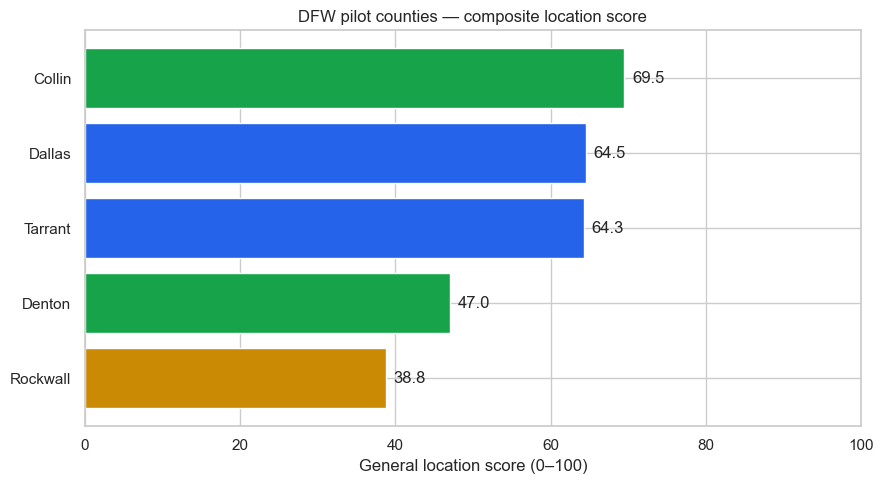

In [3]:
ranked = df.sort_values("general_location_score", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ranked["county_role"].map({
    "urban_core": "#2563eb",
    "suburban_growth": "#16a34a",
    "exurban": "#ca8a04",
})
ax.barh(ranked["county_label"], ranked["general_location_score"], color=colors)
ax.set_xlabel("General location score (0–100)")
ax.set_title("DFW pilot counties — composite location score")
ax.set_xlim(0, 100)
for i, score in enumerate(ranked["general_location_score"]):
    ax.text(score + 1, i, f"{score:.1f}", va="center")
plt.tight_layout()
plt.show()

## 3. Key market metrics side-by-side

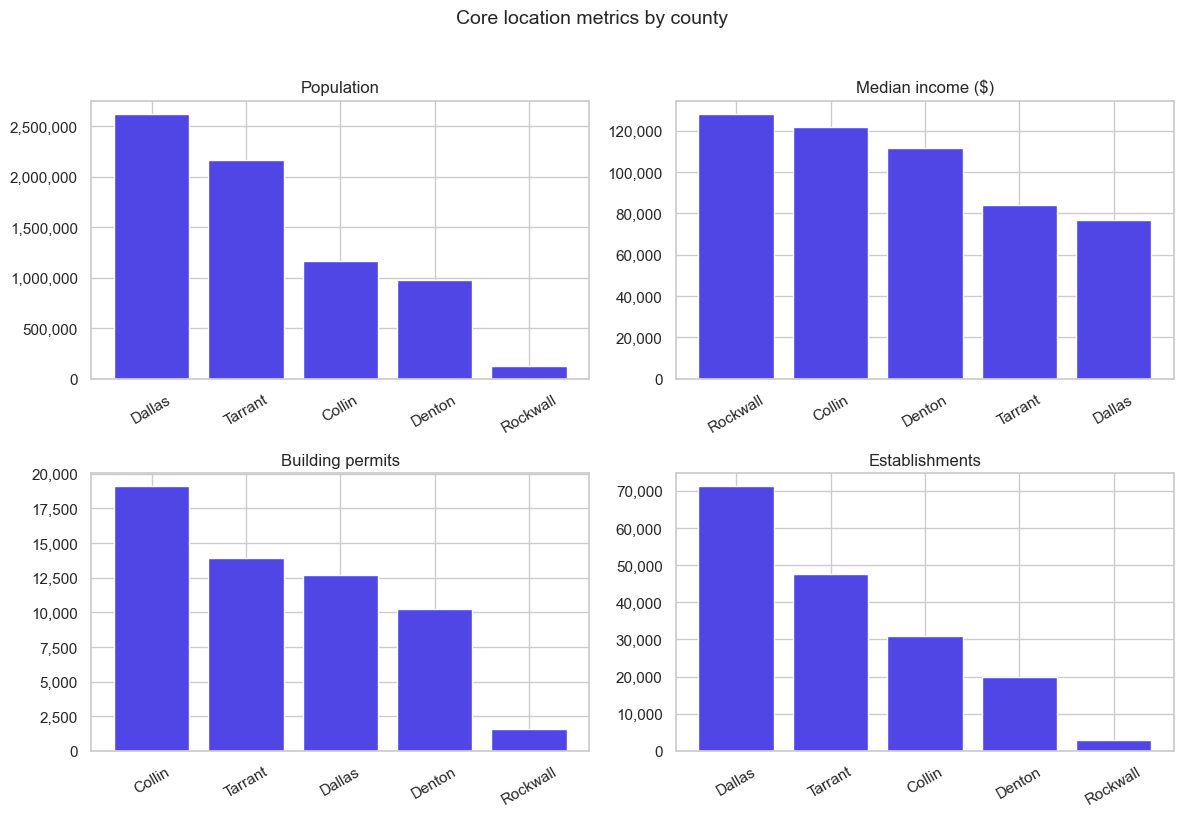

In [4]:
metrics = {
    "Population": "population",
    "Median income ($)": "median_household_income",
    "Building permits": "building_permits_latest",
    "Establishments": "total_establishments",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (title, col) in zip(axes, metrics.items()):
    plot_df = df.sort_values(col, ascending=False)
    ax.bar(plot_df["county_label"], plot_df[col], color="#4f46e5")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    ax.yaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")

plt.suptitle("Core location metrics by county", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 4. Growth vs. scale — permits and population

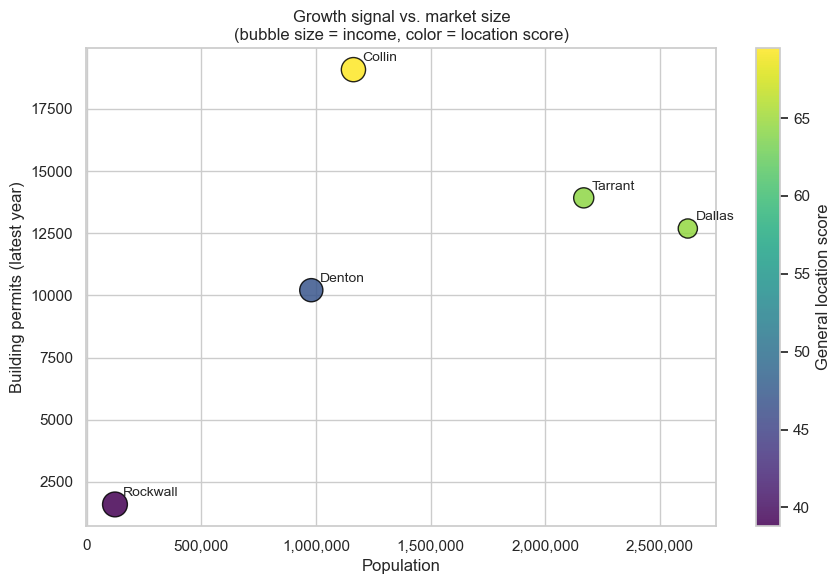

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    df["population"],
    df["building_permits_latest"],
    s=df["median_household_income"] / 400,
    c=df["general_location_score"],
    cmap="viridis",
    alpha=0.85,
    edgecolors="black",
)

for _, row in df.iterrows():
    ax.annotate(row["county_label"], (row["population"], row["building_permits_latest"]),
                textcoords="offset points", xytext=(6, 6), fontsize=10)

ax.set_xlabel("Population")
ax.set_ylabel("Building permits (latest year)")
ax.set_title("Growth signal vs. market size\n(bubble size = income, color = location score)")
ax.xaxis.set_major_formatter(lambda x, p: f"{x:,.0f}")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("General location score")
plt.tight_layout()
plt.show()

## 5. Score component breakdown

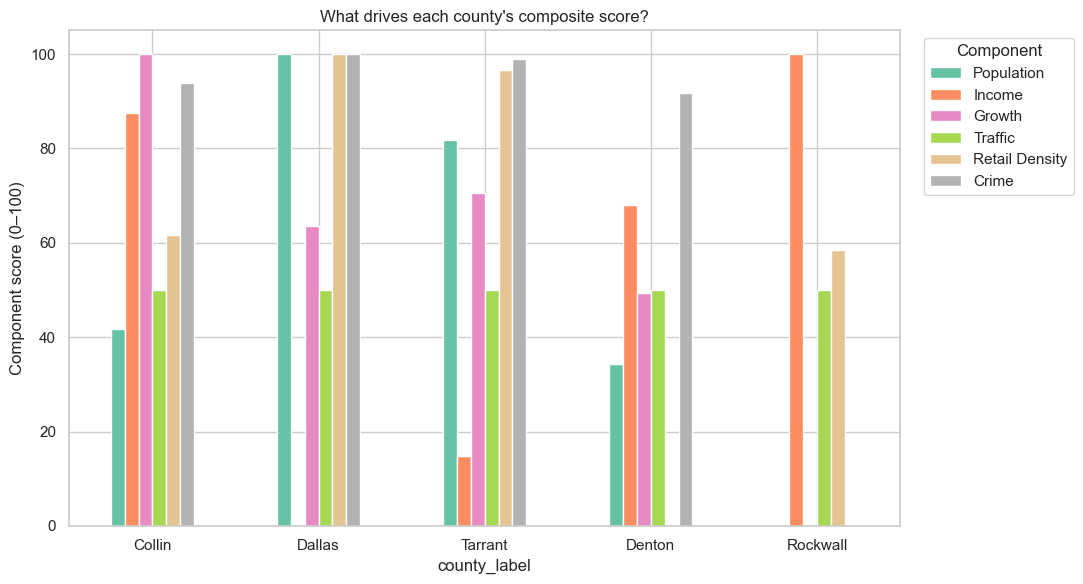

In [6]:
score_cols = [
    "score_population", "score_income", "score_growth",
    "score_traffic", "score_retail_density", "score_crime",
]
labels = [c.replace("score_", "").replace("_", " ").title() for c in score_cols]

scores = df.set_index("county_label")[score_cols]
scores.columns = labels

ax = scores.plot(kind="bar", figsize=(11, 6), colormap="Set2")
ax.set_ylabel("Component score (0–100)")
ax.set_title("What drives each county's composite score?")
ax.legend(title="Component", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Correlation heatmap

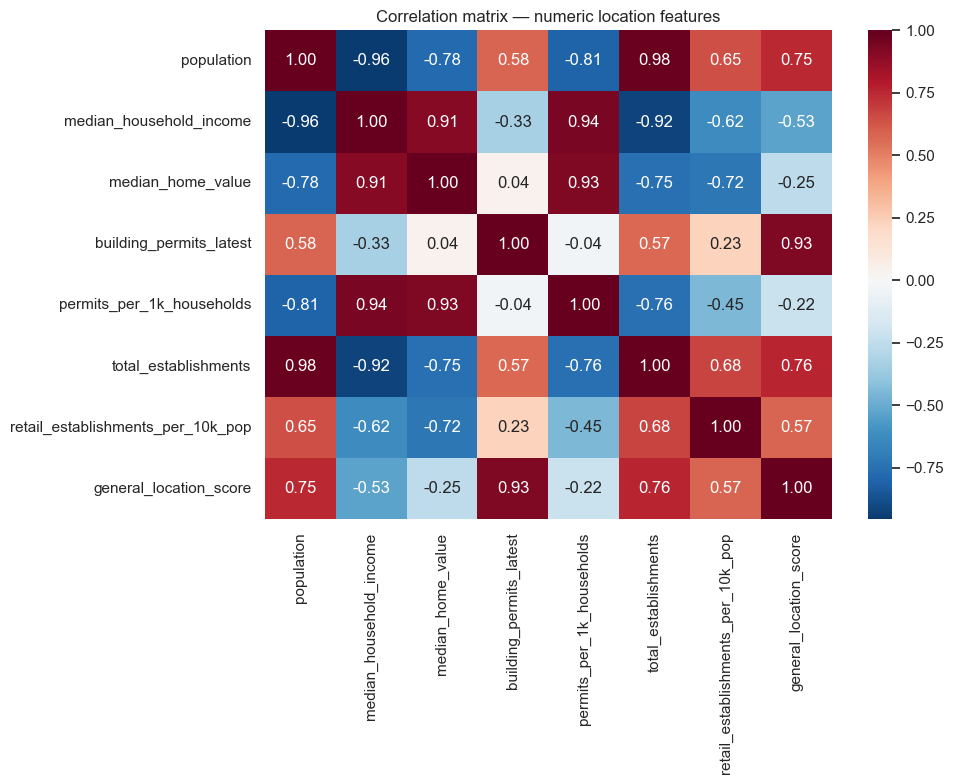

In [7]:
numeric_cols = [
    "population", "median_household_income", "median_home_value",
    "building_permits_latest", "permits_per_1k_households",
    "total_establishments", "retail_establishments_per_10k_pop",
    "general_location_score",
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation matrix — numeric location features")
plt.tight_layout()
plt.show()

## 7. Executive summary

In [8]:
top = df.loc[df["general_location_score"].idxmax()]
largest = df.loc[df["population"].idxmax()]
highest_income = df.loc[df["median_household_income"].idxmax()]
most_permits = df.loc[df["building_permits_latest"].idxmax()]

print("=== DFW Pilot — Key Takeaways ===\n")
print(f"Highest composite score: {top['county_label']} ({top['general_location_score']:.1f})")
print(f"Largest population:        {largest['county_label']} ({largest['population']:,})")
print(f"Highest median income:     {highest_income['county_label']} (${highest_income['median_household_income']:,})")
print(f"Most building permits:     {most_permits['county_label']} ({most_permits['building_permits_latest']:,})")
print()
print("Interpretation notes:")
print("- Collin leads on growth + income balance, not raw population.")
print("- Dallas has scale (population, establishments) but lower income vs. suburbs.")
print("- Rockwall has high income but small market size limits composite score.")
print("- Traffic and county-level crime are not yet reliable — treat those columns cautiously.")

=== DFW Pilot — Key Takeaways ===

Highest composite score: Collin (69.5)
Largest population:        Dallas (2,621,179)
Highest median income:     Rockwall ($127,981)
Most building permits:     Collin (19,082)

Interpretation notes:
- Collin leads on growth + income balance, not raw population.
- Dallas has scale (population, establishments) but lower income vs. suburbs.
- Rockwall has high income but small market size limits composite score.
- Traffic and county-level crime are not yet reliable — treat those columns cautiously.
